# 🏥 Disease Predictor — Multi-Class Classification

**Objective:** Build a machine-learning model that predicts a disease from a set of binary symptom features.

| Dataset | Rows | Columns |
|---------|------|---------|
| Training.csv | 4 920 | 133 symptoms + 1 target |
| Testing.csv | 42 | 133 symptoms + 1 target |

---

### 📋 Table of Contents
1. [Imports & Configuration](#1)
2. [Data Loading](#2)
3. [Data Cleaning](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature Engineering](#5)
6. [Model Training & Cross-Validation](#6)
7. [Model Evaluation on Test Set](#7)
8. [Model Export](#8)
9. [Conclusion](#9)

<a id="1"></a>
## 1. 📦 Imports & Configuration

In [1]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Scikit-learn ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
import joblib

# ── DONT KNOW ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


<a id="2"></a>
## 2. 📥 Data Loading

In [2]:
# Load datasets
df_train = pd.read_csv("Training.csv")
df_test  = pd.read_csv("Testing.csv")

print(f"Training set shape : {df_train.shape}")
print(f"Testing  set shape : {df_test.shape}")

Training set shape : (4920, 134)
Testing  set shape : (42, 133)


In [3]:
df_train.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [5]:
df_train.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='object', length=134)

In [107]:
df_train.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB


In [108]:
df_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
itching,4920.0,0.137805,0.344730,0.0,0.0,0.0,0.0,1.0
skin_rash,4920.0,0.159756,0.366417,0.0,0.0,0.0,0.0,1.0
nodal_skin_eruptions,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
continuous_sneezing,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
shivering,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0
chills,4920.0,0.162195,0.368667,0.0,0.0,0.0,0.0,1.0
joint_pain,4920.0,0.139024,0.346007,0.0,0.0,0.0,0.0,1.0
stomach_pain,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
acidity,4920.0,0.045122,0.207593,0.0,0.0,0.0,0.0,1.0
ulcers_on_tongue,4920.0,0.021951,0.146539,0.0,0.0,0.0,0.0,1.0


<a id="3"></a>
## 3. 🧹 Data Cleaning

### 3.1 Drop Junk Columns

In [109]:
if "Unnamed: 133" in df_train.columns:
    df_train.drop(columns=["Unnamed: 133"], inplace=True)
    print("Dropped 'Unnamed: 133' from training set.")

print(f"Training columns after cleanup: {df_train.shape[1]}")

Dropped 'Unnamed: 133' from training set.
Training columns after cleanup: 133


### 3.2 Missing Values

In [110]:
missing = df_train.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("No missing values found in training set.")
else:
    print("Columns with missing values:")
    print(missing_cols.sort_values(ascending=False))

No missing values found in training set.


In [111]:
missing_test = df_test.isnull().sum()
missing_test_cols = missing_test[missing_test > 0]

if missing_test_cols.empty:
    print("No missing values found in testing set.")
else:
    print("Columns with missing values in test set:")
    print(missing_test_cols.sort_values(ascending=False))

No missing values found in testing set.


### 3.4 Verify Binary Feature Integrity

In [112]:
df_train

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo
4916,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary tract infection
4918,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis


In [113]:
symptom_cols = [c for c in df_train.columns if c != "prognosis"]

invalid_cols = [
    col for col in symptom_cols
    if not set(df_train[col].unique()).issubset({0, 1})
]

if len(invalid_cols) == 0:
    print("All symptom features are valid binary (0/1) columns.")
else:
    print("Invalid columns:", invalid_cols)

All symptom features are valid binary (0/1) columns.


### 3.5 Clean Target Labels

In [114]:
df_train["prognosis"] = df_train["prognosis"].str.strip()
df_test["prognosis"]  = df_test["prognosis"].str.strip()

print(f"Unique diseases in training set: {df_train['prognosis'].nunique()}")
print(f"Unique diseases in testing  set: {df_test['prognosis'].nunique()}")

Unique diseases in training set: 41
Unique diseases in testing  set: 41


In [115]:
df_train["prognosis"].value_counts()

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

In [116]:
df_train["prognosis"].value_counts().unique()

array([120])

In [117]:
df_train.shape

(4920, 133)

<a id="4"></a>
## 4. 📊 Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

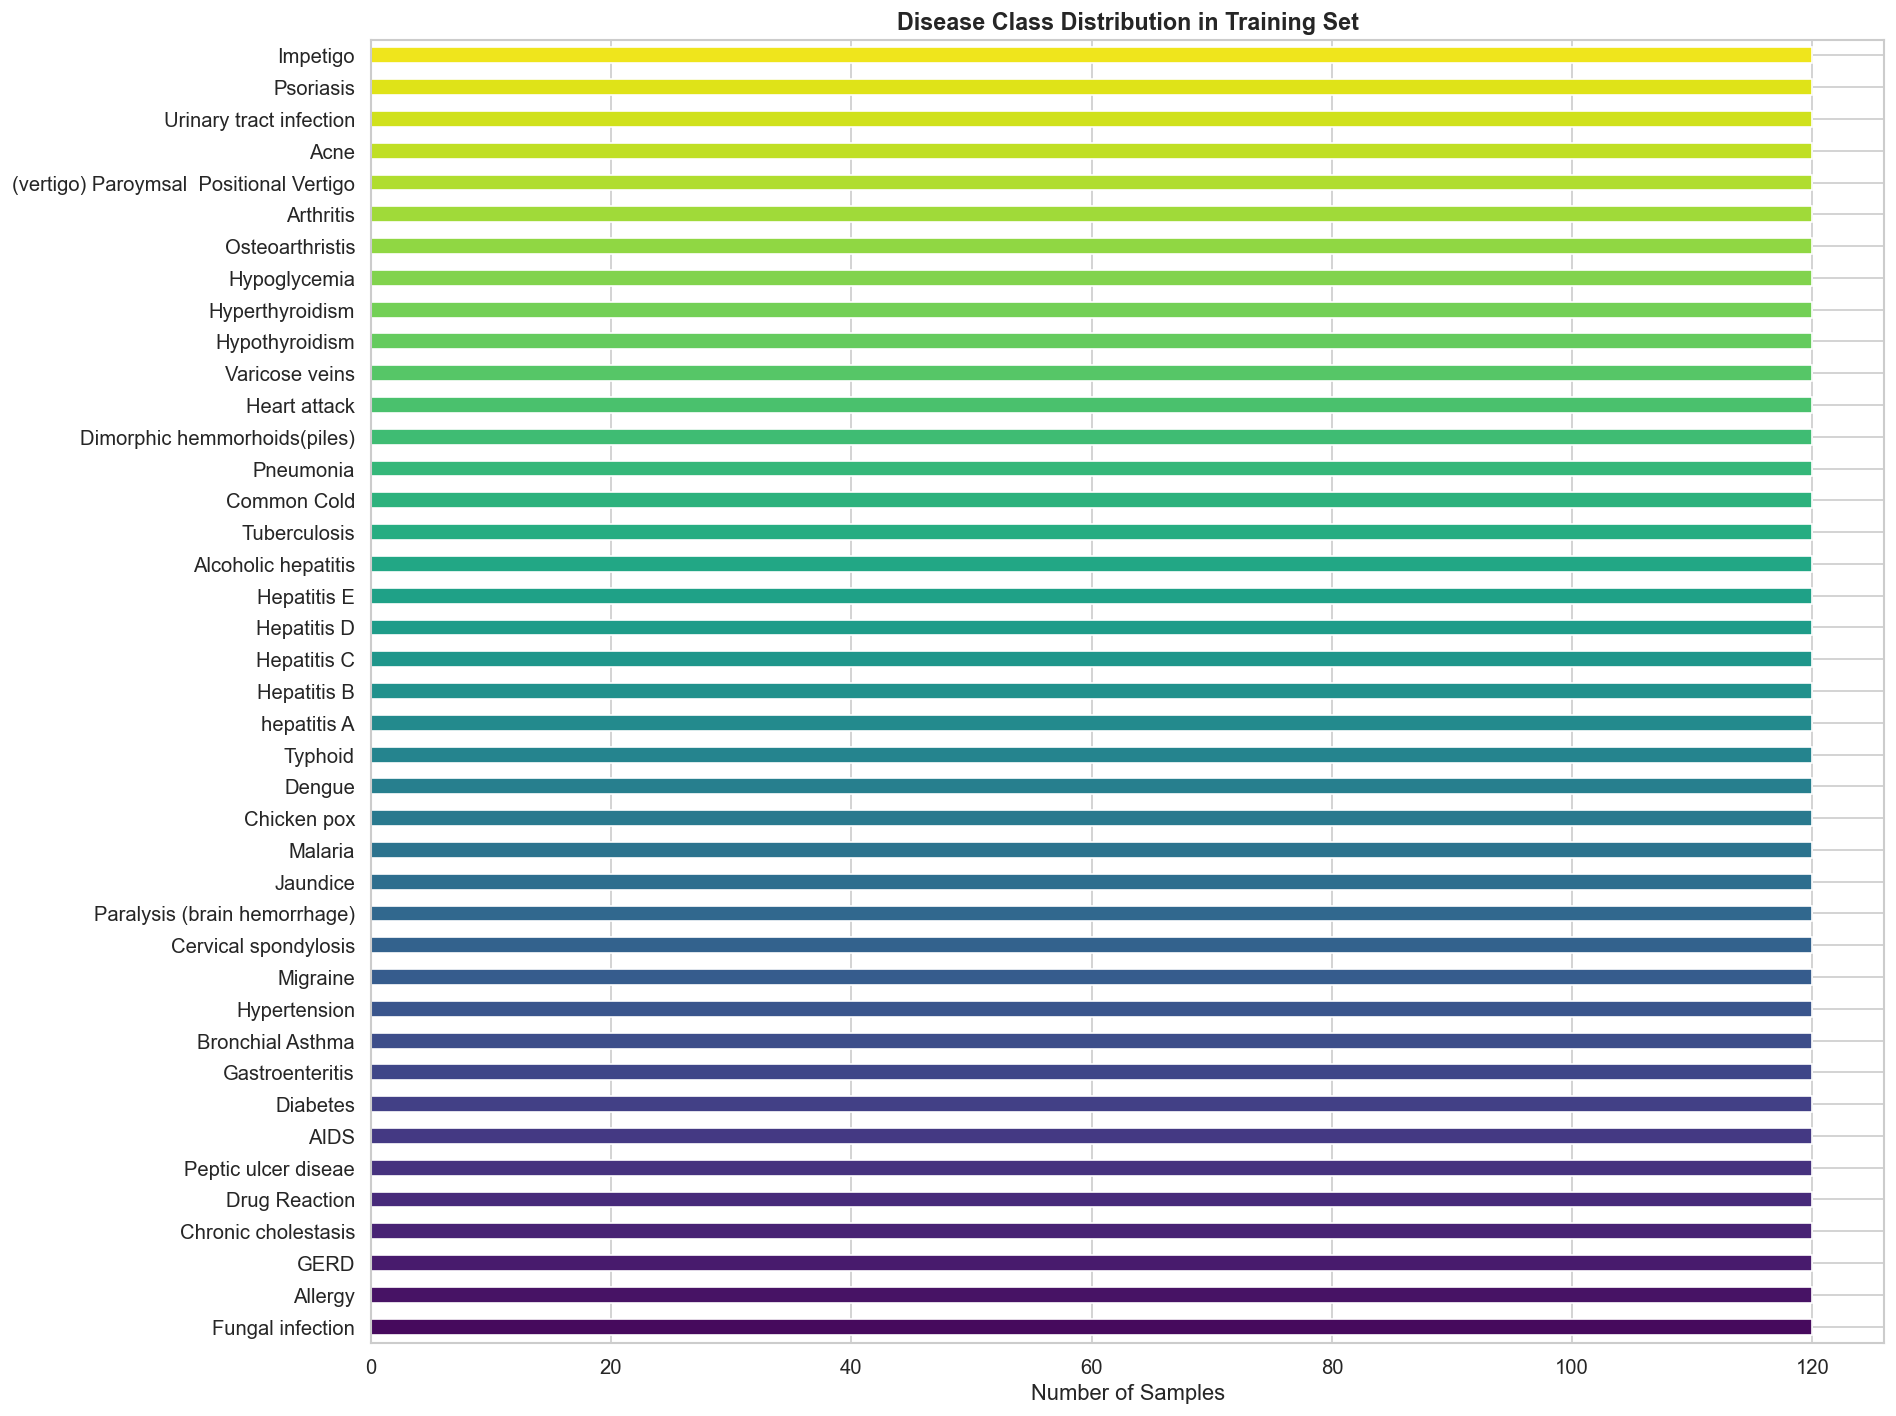

In [118]:
plt.figure(figsize=(16, 12))
disease_counts = df_train["prognosis"].value_counts().sort_values()
disease_counts.plot.barh(color=sns.color_palette("viridis", len(disease_counts)))
plt.xlabel("Number of Samples")
plt.ylabel("")
plt.title("Disease Class Distribution in Training Set", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.2 Top 20 Most Frequent Symptoms

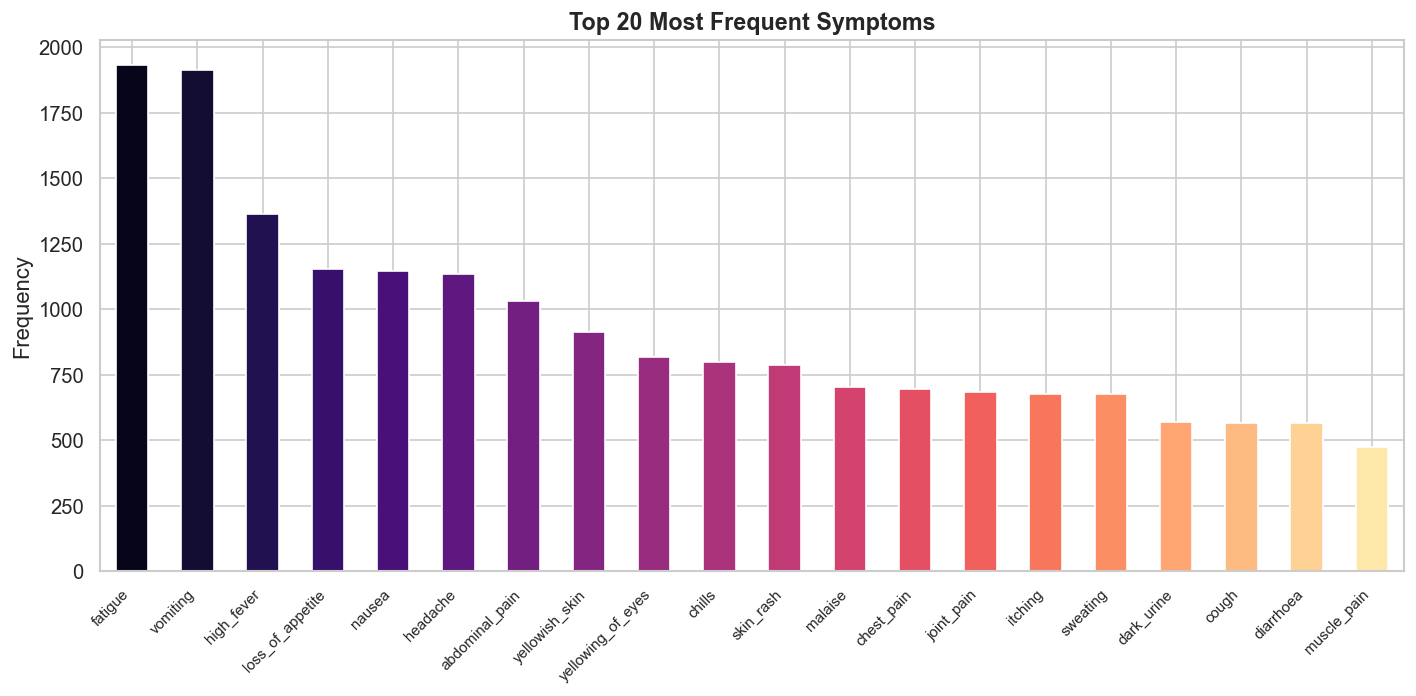

In [119]:
top20 = df_train[symptom_cols].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))

top20.plot.bar(
    color=sns.color_palette("magma", len(top20))
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Symptoms", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.3 Average Symptom Count per Disease

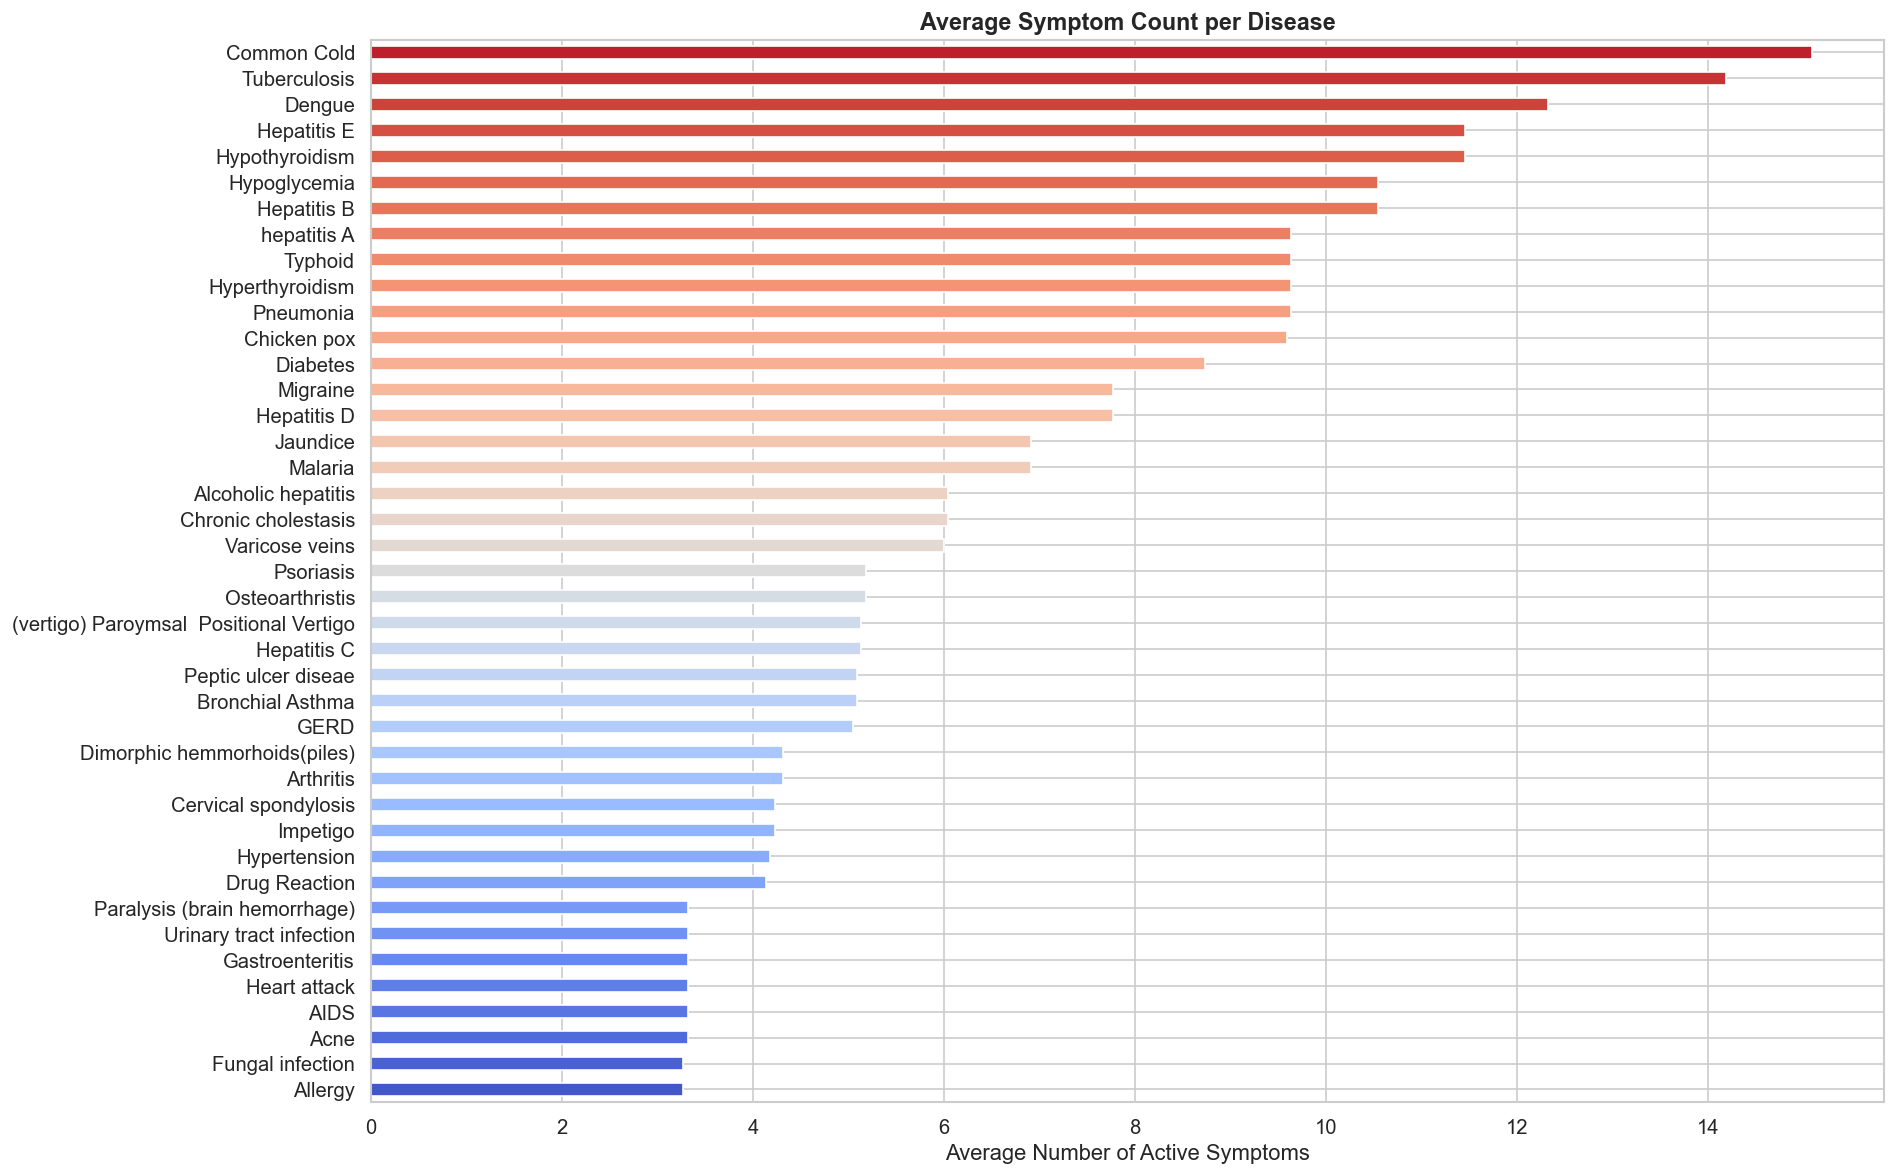

In [120]:
symptom_count_per_disease = (
    df_train.groupby("prognosis")[symptom_cols]
    .sum()
    .mean(axis=1)
    .sort_values()
)

plt.figure(figsize=(16, 10))

symptom_count_per_disease.plot.barh(
    color=sns.color_palette("coolwarm", len(symptom_count_per_disease))
)

plt.xlabel("Average Number of Active Symptoms")
plt.ylabel("")
plt.title("Average Symptom Count per Disease", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

<a id="5"></a>
## 5.  Feature Engineering

### 5.1 Add Symptom Count Feature
Adding the **total number of active symptoms** as an extra feature — this gives models a global signal about disease severity.

In [ ]:
df_train["symptom_count"] = df_train[symptom_cols].sum(axis=1)
df_test["symptom_count"]  = df_test[[c for c in symptom_cols if c in df_test.columns]].sum(axis=1)

print(f"  Training range: {df_train['symptom_count'].min()} – {df_train['symptom_count'].max()}")
print(f"  Testing  range: {df_test['symptom_count'].min()} – {df_test['symptom_count'].max()}")

  Training range: 3 – 17
  Testing  range: 4 – 17


### 5.2 Remove Zero-Variance Features
Features that are always 0 (never activated across the entire training set) provide no discriminative power.

In [122]:
# Identify zero-variance symptom columns
zero_var_cols = [c for c in symptom_cols if df_train[c].nunique() <= 1]
print(f"Zero-variance columns found: {len(zero_var_cols)}")

if zero_var_cols:
    print("Dropping:", zero_var_cols)
    df_train.drop(columns=zero_var_cols, inplace=True)
    # Only drop from test if they exist
    existing_in_test = [c for c in zero_var_cols if c in df_test.columns]
    df_test.drop(columns=existing_in_test, inplace=True)
else:
    print("✅ No zero-variance columns to remove.")

# Update symptom_cols list
symptom_cols = [c for c in df_train.columns if c not in ["prognosis", "symptom_count"]]
print(f"\nFinal feature count: {len(symptom_cols)} symptoms + 1 symptom_count = {len(symptom_cols)+1} features")

Zero-variance columns found: 1
Dropping: ['fluid_overload']

Final feature count: 131 symptoms + 1 symptom_count = 132 features


<a id="6"></a>
## 6. Model Training

In [123]:
feature_cols = [c for c in df_train.columns if c != "prognosis"]
X_train = df_train[feature_cols]
y_train = df_train["prognosis"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Classes: {y_train.nunique()}")

X_train shape: (4920, 132)
y_train shape: (4920,)
Classes: 41


In [124]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=SEED),
    "SVM": SVC(kernel="rbf", random_state=SEED)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv)

    print(name)
    print("Mean Accuracy:", scores.mean())
    print("Std Dev:", scores.std())
    print()

Random Forest
Mean Accuracy: 1.0
Std Dev: 0.0

Logistic Regression
Mean Accuracy: 1.0
Std Dev: 0.0

SVM
Mean Accuracy: 1.0
Std Dev: 0.0



In [125]:
# Train all models on the full training set
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} trained on full training set.")

✅ Random Forest trained on full training set.
✅ Logistic Regression trained on full training set.
✅ SVM trained on full training set.


<a id="7"></a>
## 7. Model Evaluation on Test Set

### 7.1 Prepare Test Data

In [126]:
# Align test features with training features
X_test = df_test.reindex(columns=feature_cols, fill_value=0)
y_test = df_test["prognosis"]

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (42, 132)
y_test shape: (42,)


### 7.2 Evaluate Each Model

In [127]:
# Evaluate all models on test set
test_accuracies = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies[name] = acc
    
    print("=" * 70)
    print(f"  📌 {name}  --->  Test Accuracy: {acc:.4f}")
    print("=" * 70)
    print()
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

  📌 Random Forest  --->  Test Accuracy: 0.9762

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00

### 7.3 Confusion Matrices

In [128]:
print(model.classes_)

['(vertigo) Paroymsal  Positional Vertigo' 'AIDS' 'Acne'
 'Alcoholic hepatitis' 'Allergy' 'Arthritis' 'Bronchial Asthma'
 'Cervical spondylosis' 'Chicken pox' 'Chronic cholestasis' 'Common Cold'
 'Dengue' 'Diabetes' 'Dimorphic hemmorhoids(piles)' 'Drug Reaction'
 'Fungal infection' 'GERD' 'Gastroenteritis' 'Heart attack' 'Hepatitis B'
 'Hepatitis C' 'Hepatitis D' 'Hepatitis E' 'Hypertension'
 'Hyperthyroidism' 'Hypoglycemia' 'Hypothyroidism' 'Impetigo' 'Jaundice'
 'Malaria' 'Migraine' 'Osteoarthristis' 'Paralysis (brain hemorrhage)'
 'Peptic ulcer diseae' 'Pneumonia' 'Psoriasis' 'Tuberculosis' 'Typhoid'
 'Urinary tract infection' 'Varicose veins' 'hepatitis A']


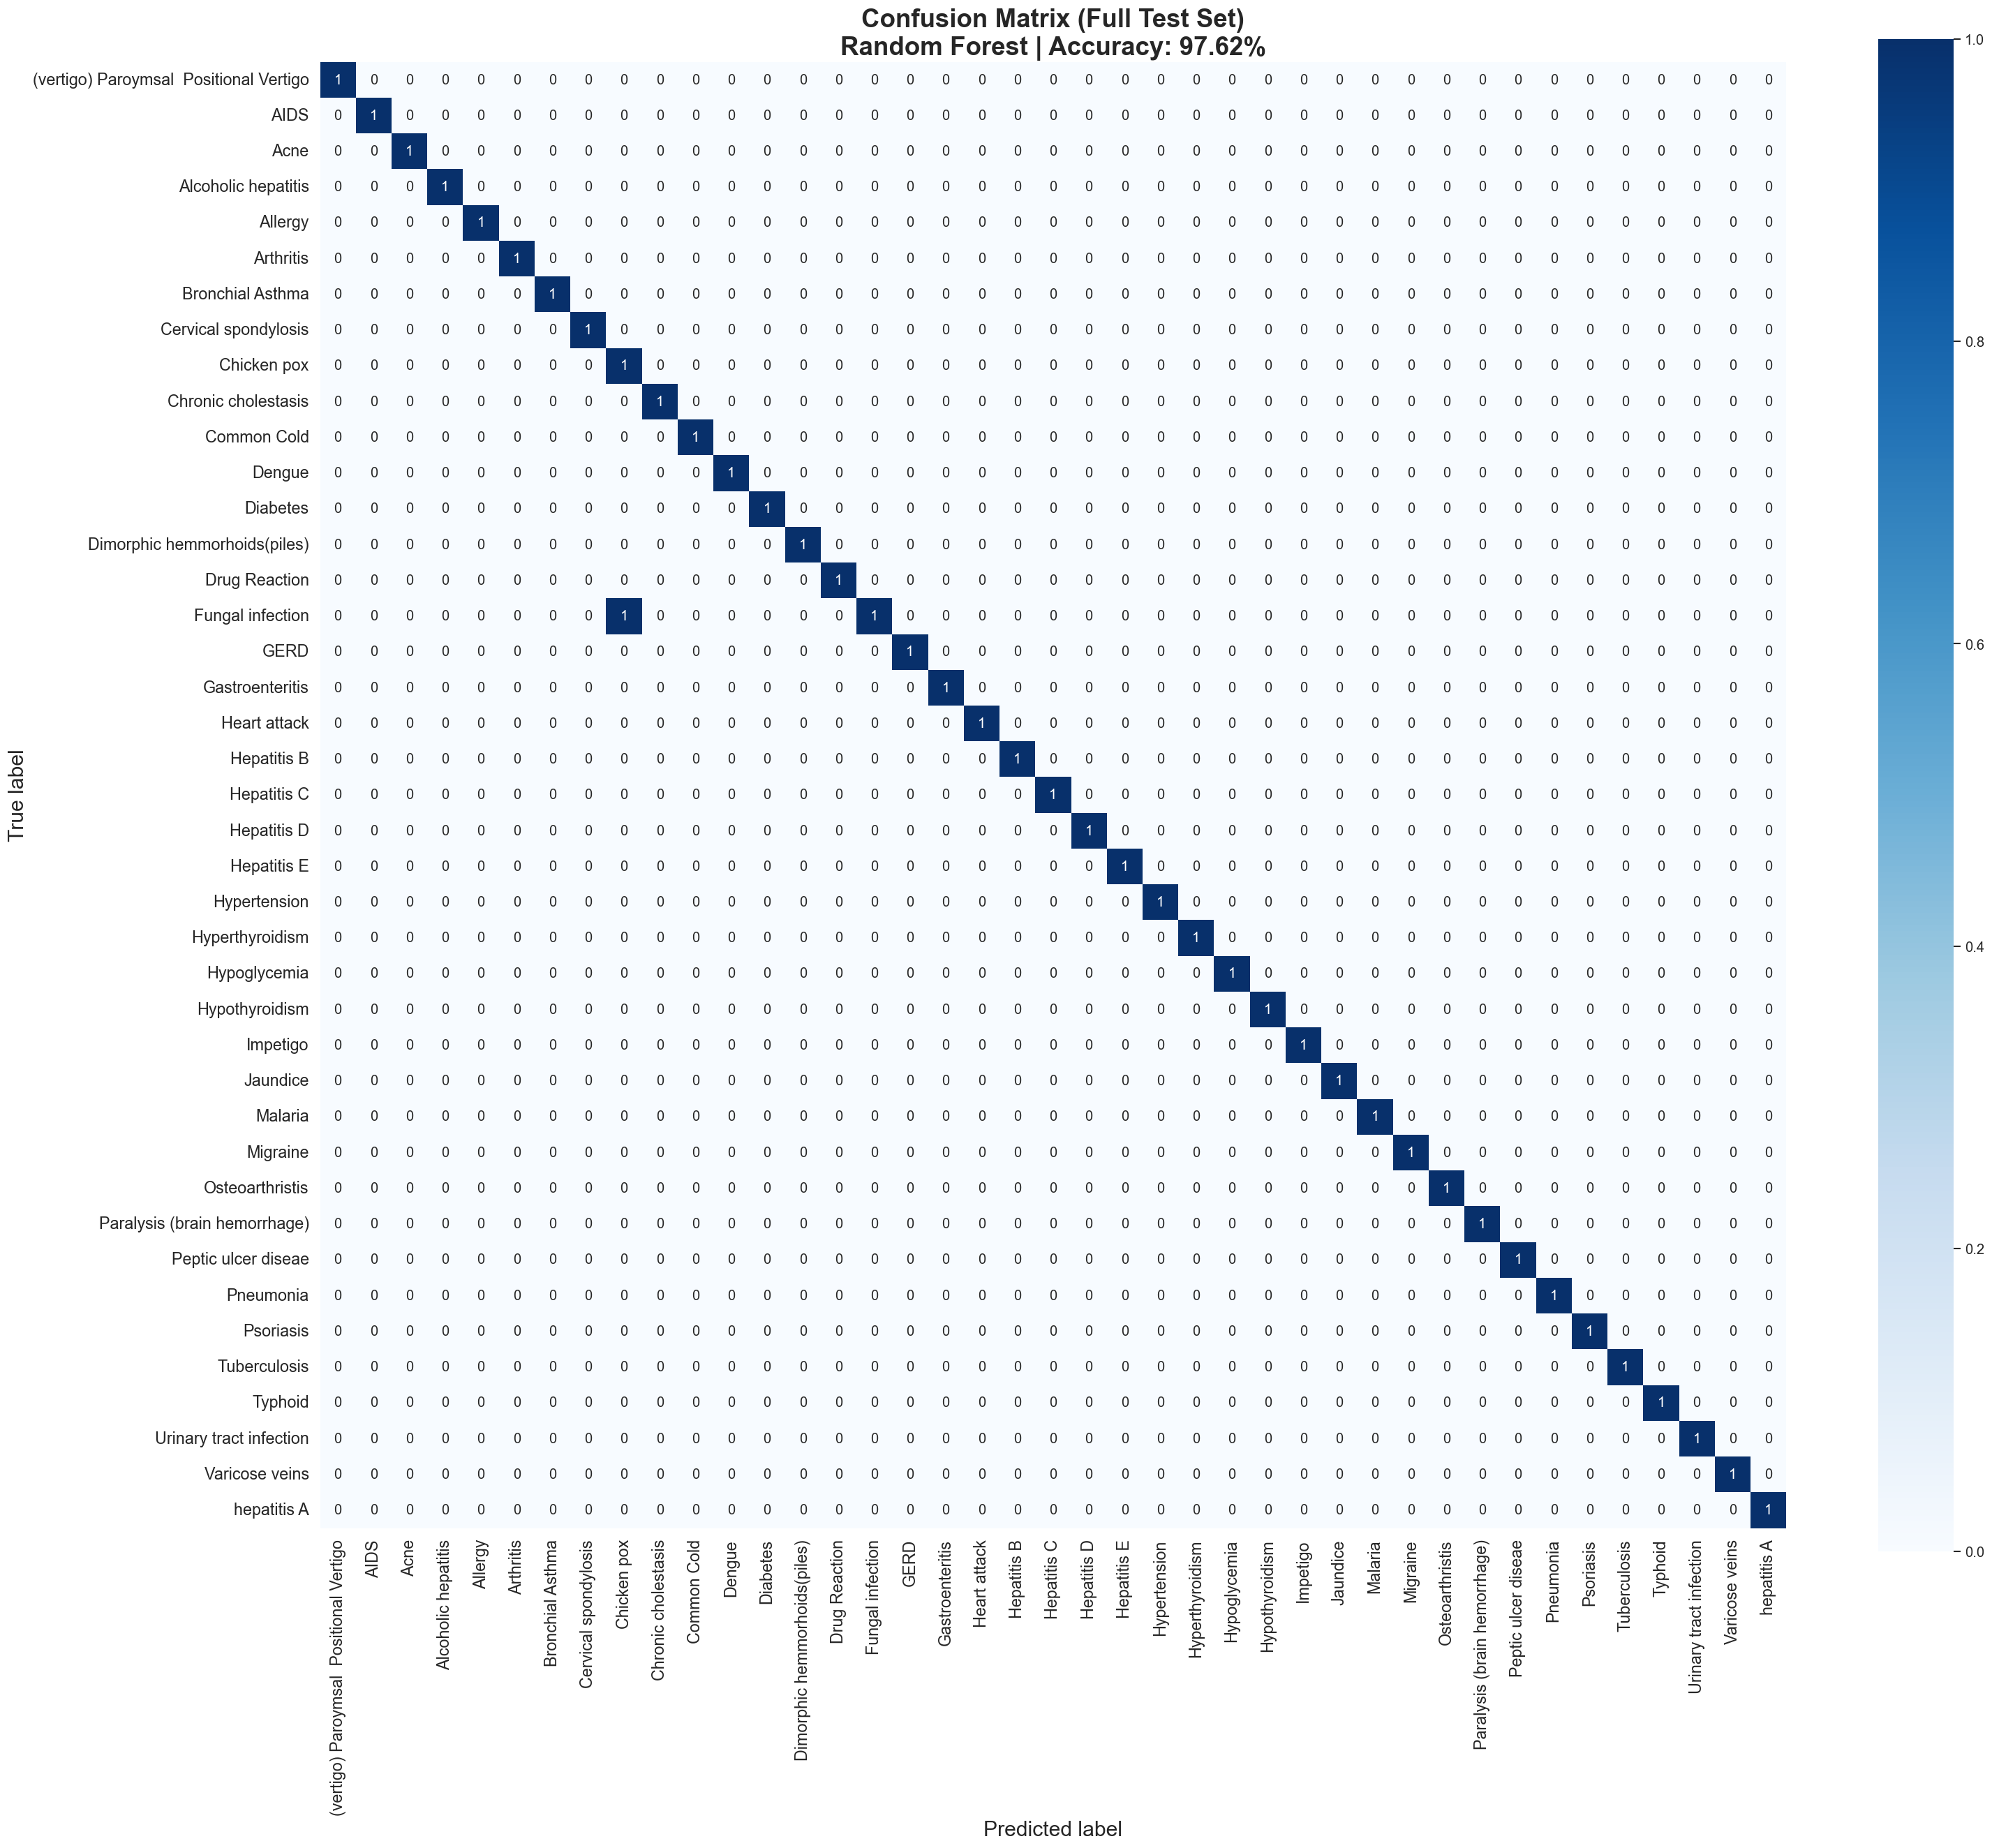

In [129]:
model = trained_models["Random Forest"]

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(26,22))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cbar=True,
    square=True,
    annot_kws={"size":12}
)

plt.xticks(rotation=90, fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.xlabel("Predicted label", fontsize=18)
plt.ylabel("True label", fontsize=18)

plt.title(
    f"Confusion Matrix (Full Test Set)\nRandom Forest | Accuracy: {test_accuracies['Random Forest']:.2%}",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

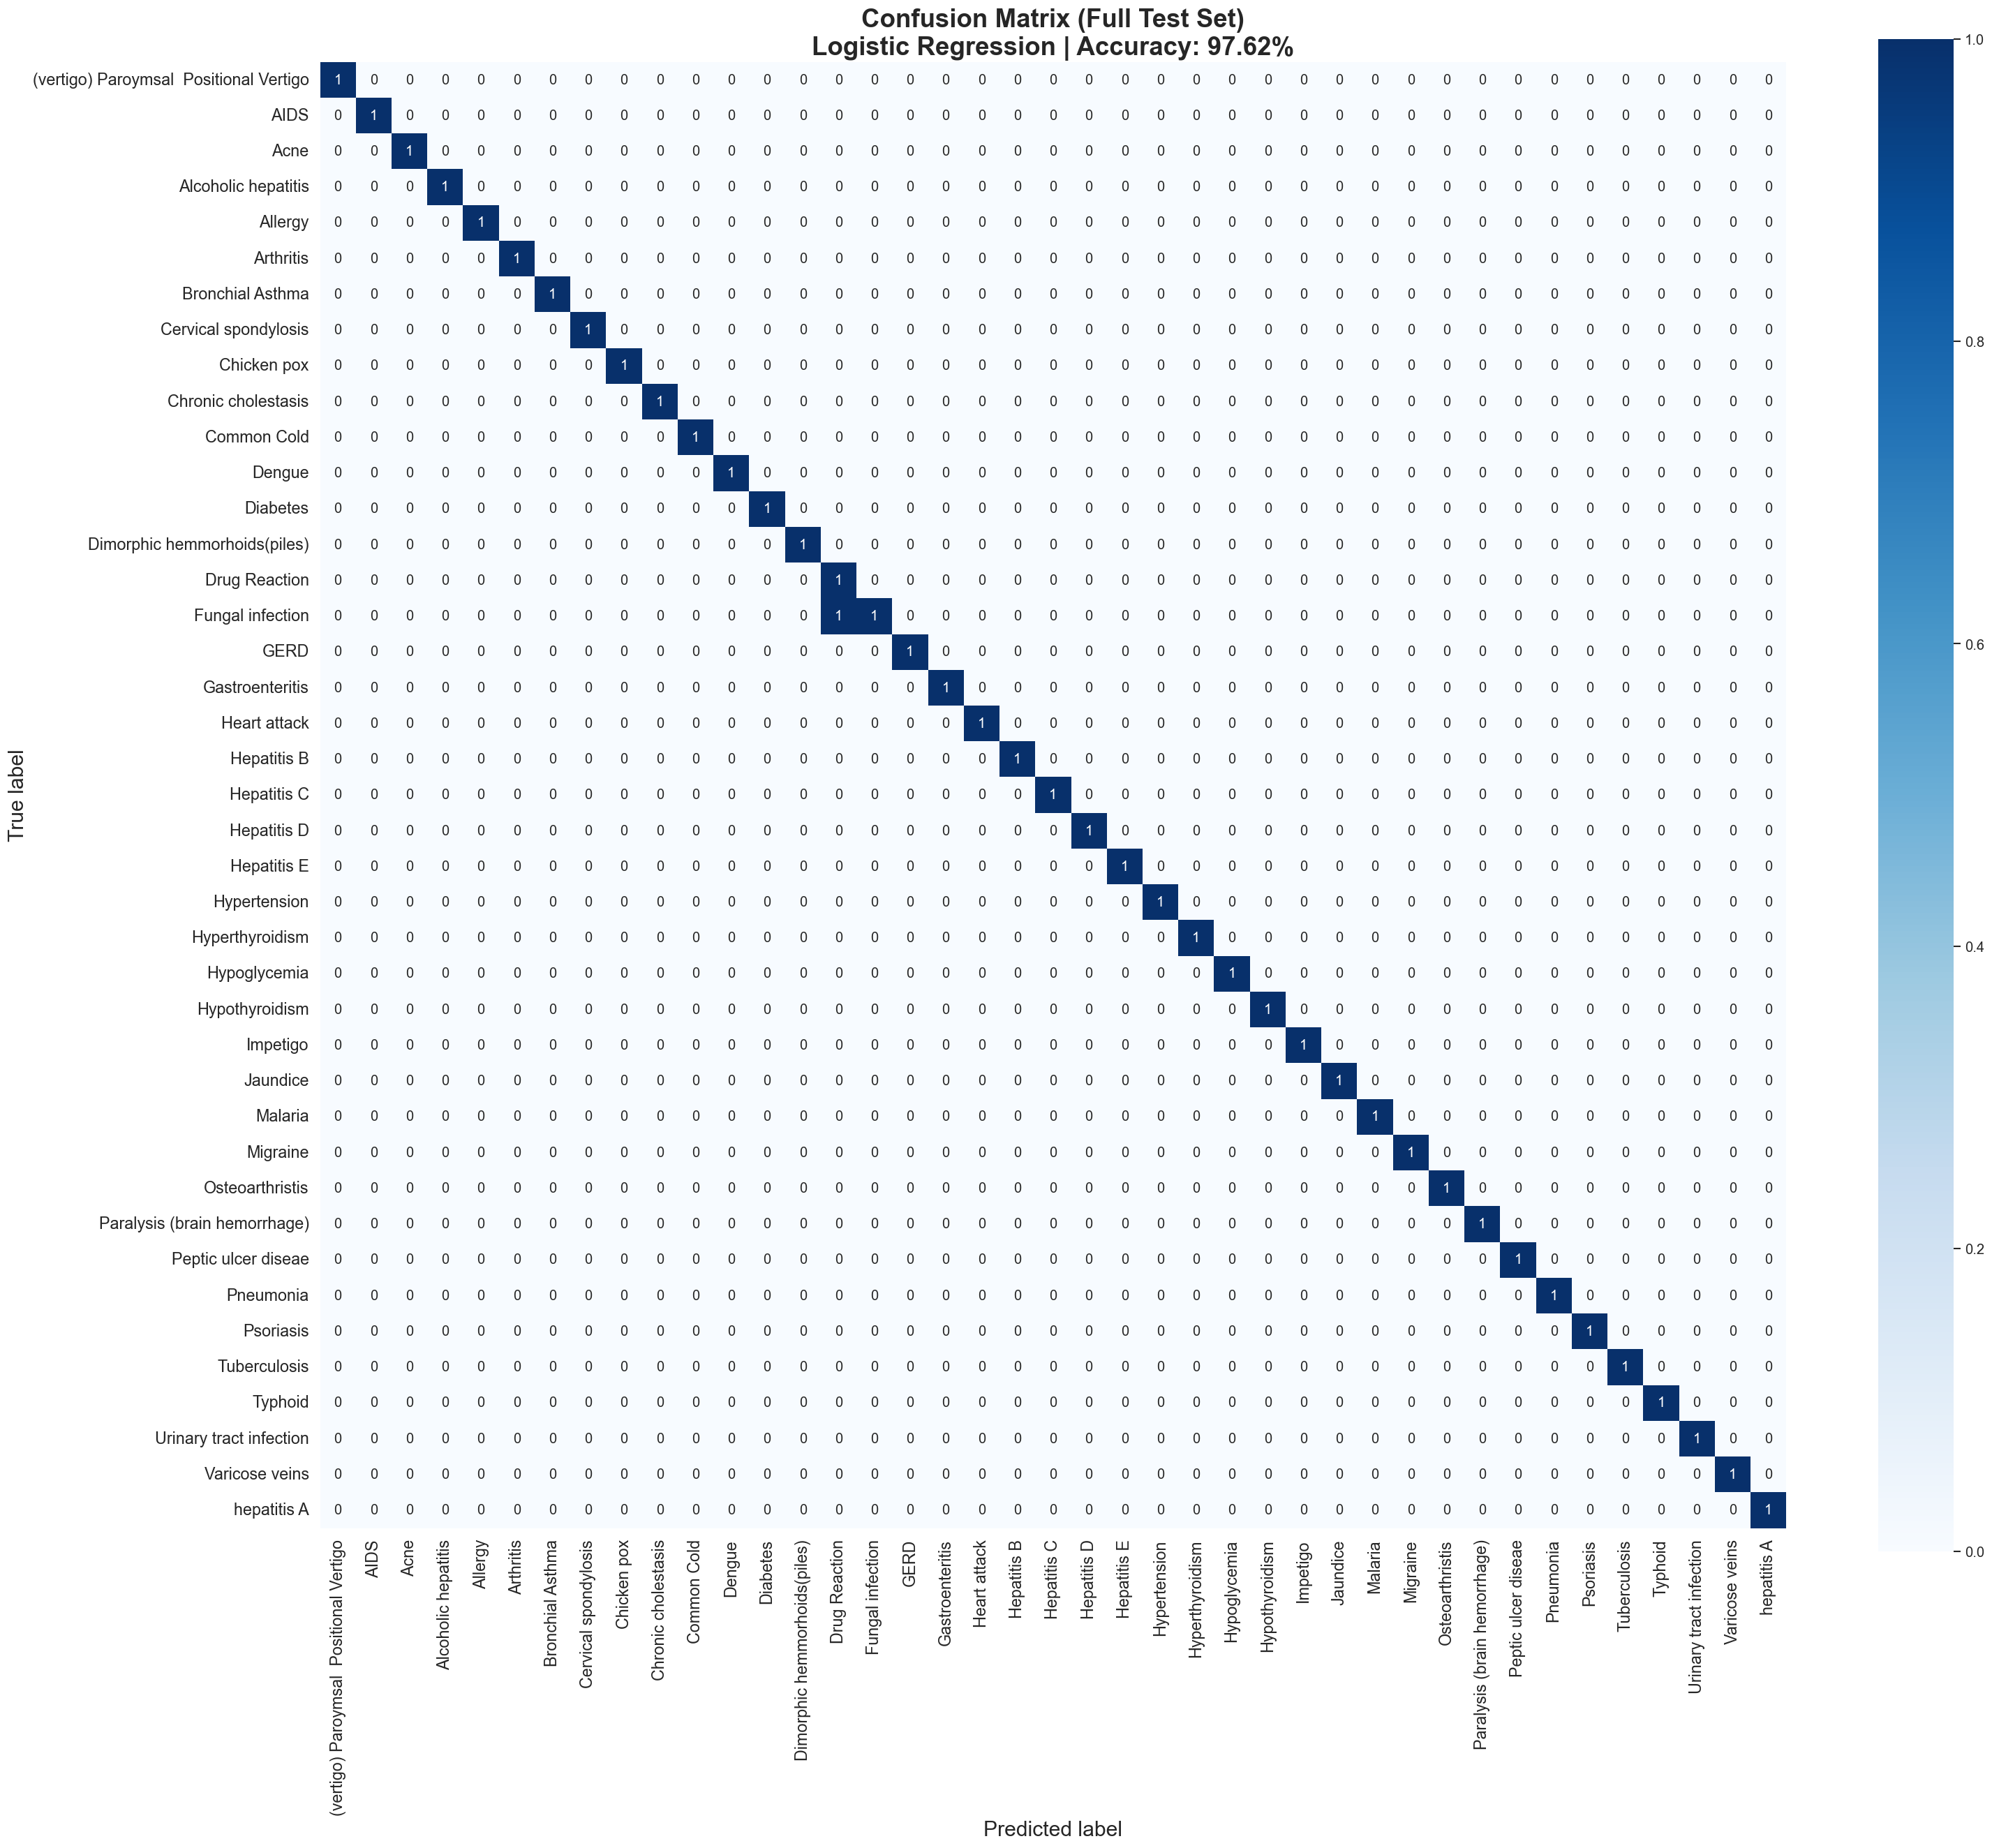

In [130]:
model = trained_models["Logistic Regression"]

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(26,22))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cbar=True,
    square=True,
    annot_kws={"size":12}
)

plt.xticks(rotation=90, fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.xlabel("Predicted label", fontsize=18)
plt.ylabel("True label", fontsize=18)

plt.title(
    f"Confusion Matrix (Full Test Set)\nLogistic Regression | Accuracy: {test_accuracies['Logistic Regression']:.2%}",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

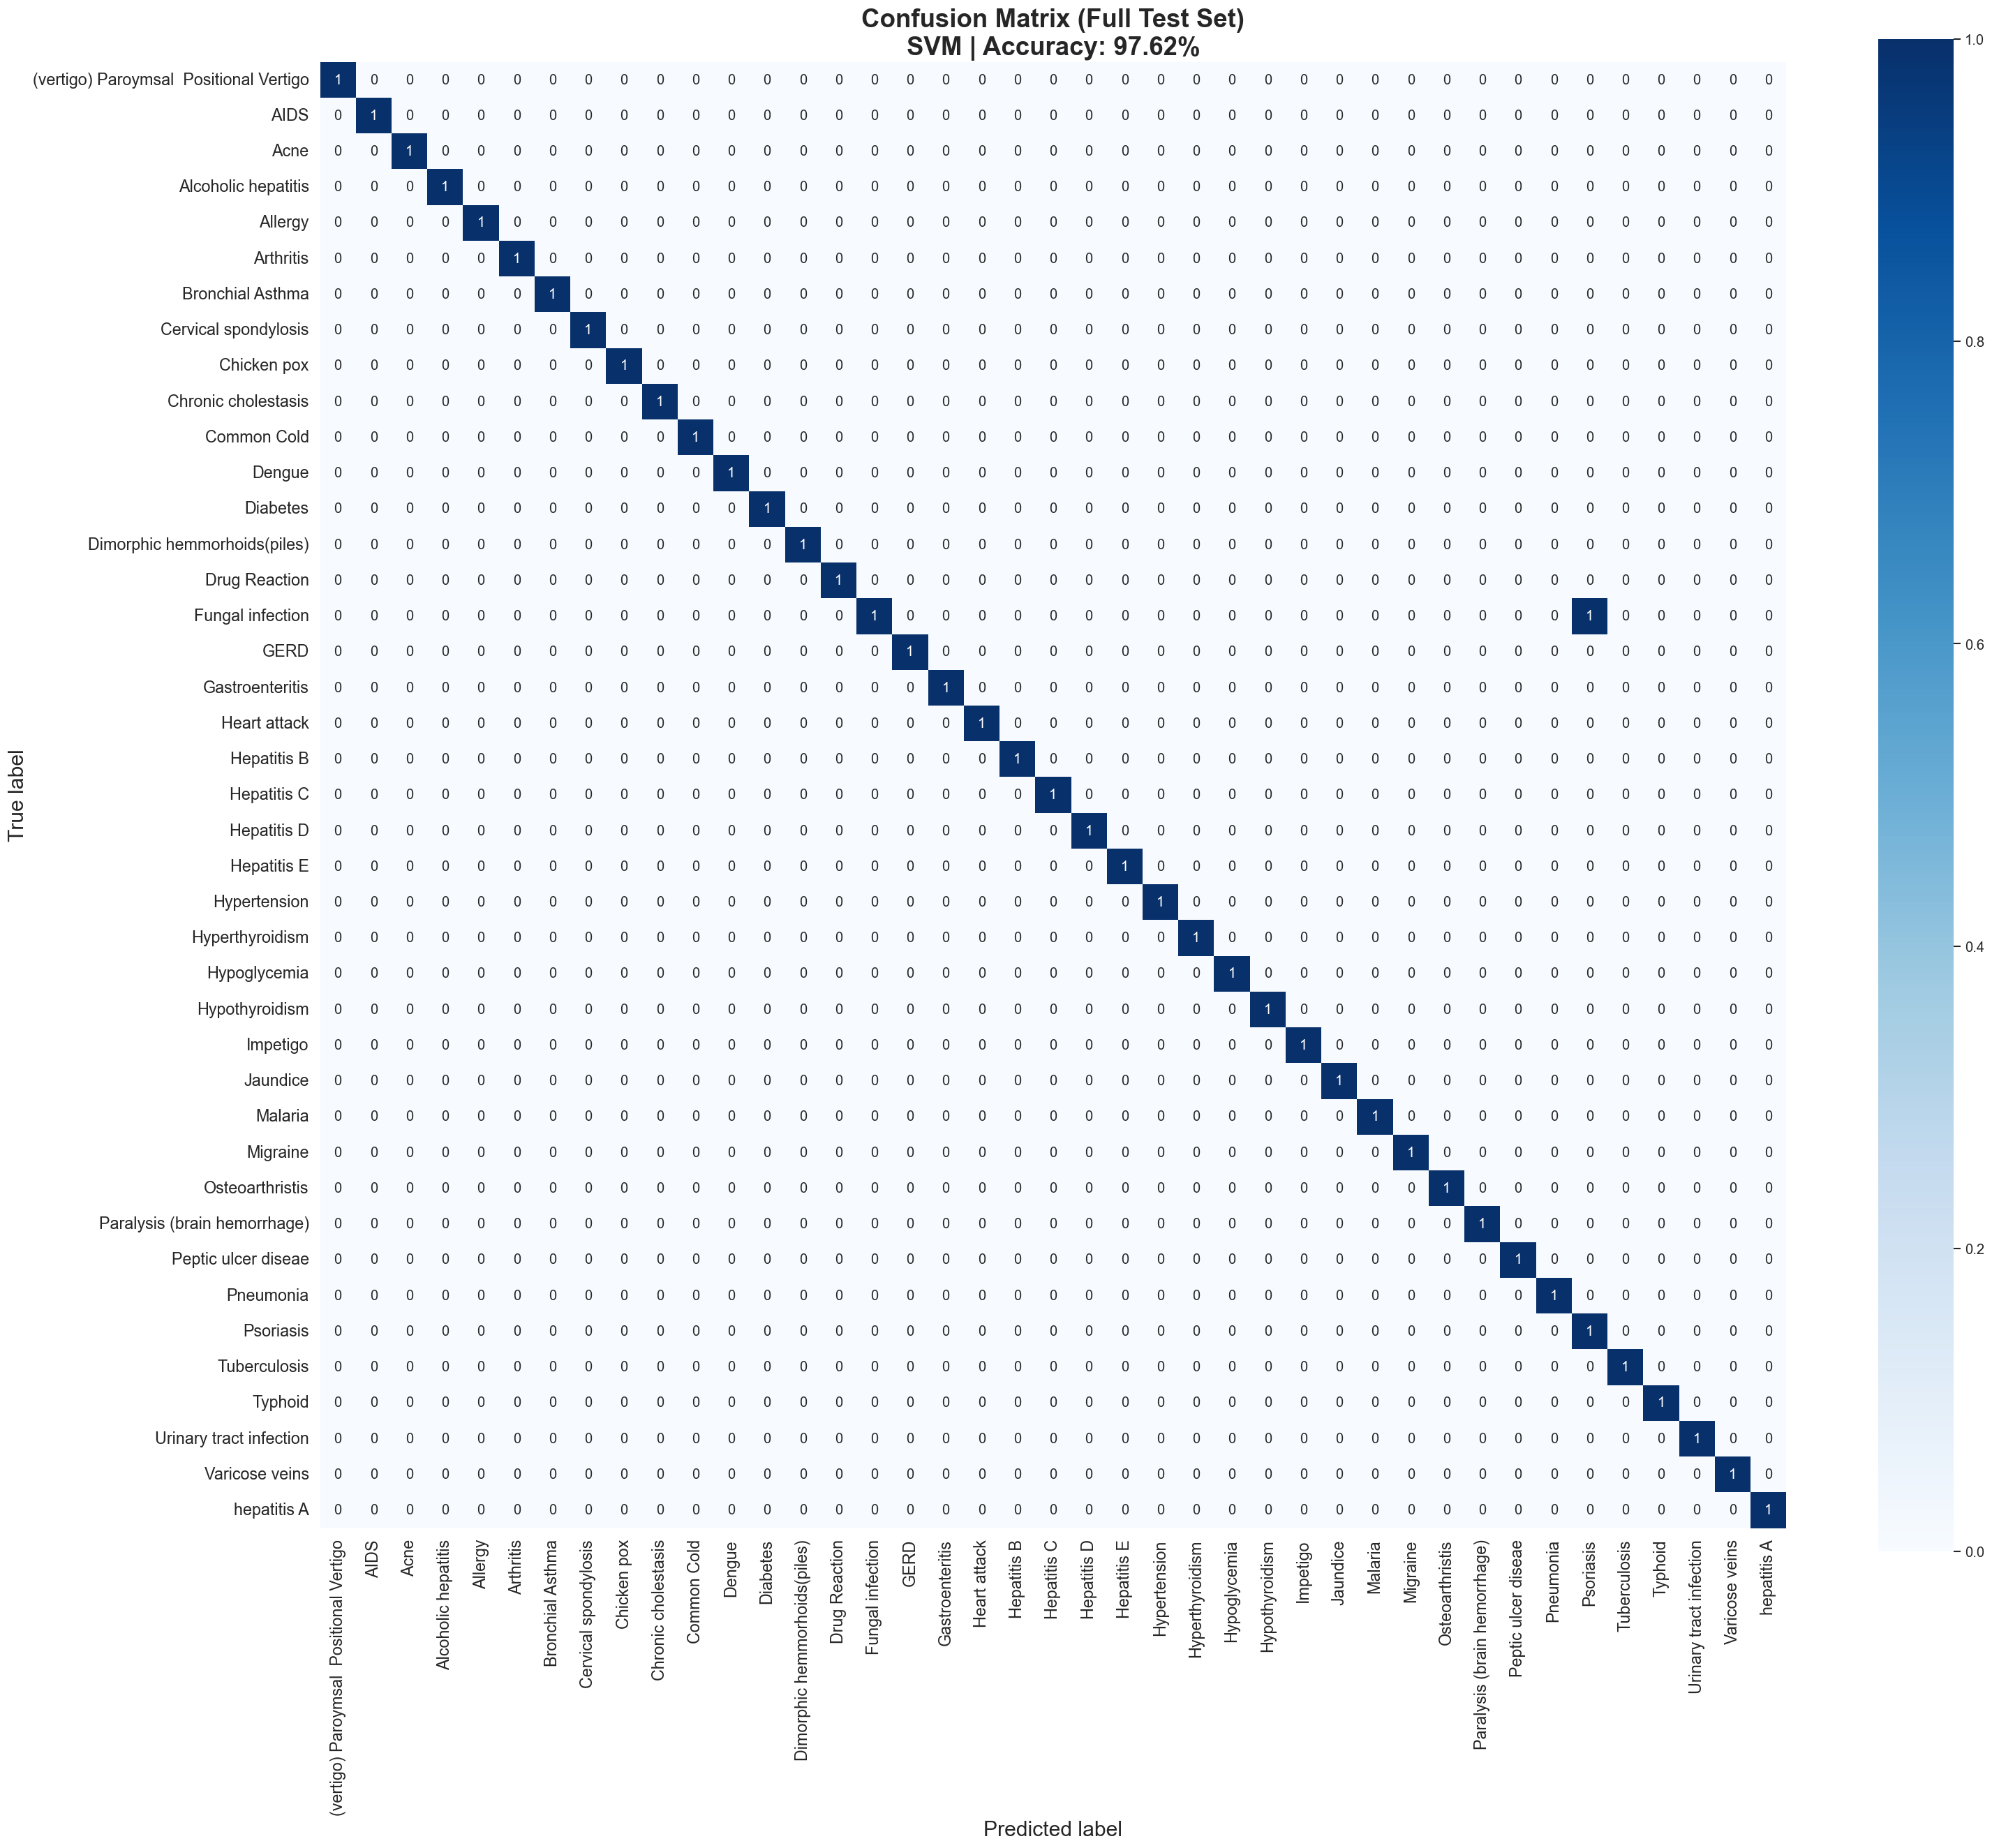

In [131]:
model = trained_models["SVM"]

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(26,22))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cbar=True,
    square=True,
    annot_kws={"size":12}
)

plt.xticks(rotation=90, fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.xlabel("Predicted label", fontsize=18)
plt.ylabel("True label", fontsize=18)

plt.title(
    f"Confusion Matrix (Full Test Set)\nSVM | Accuracy: {test_accuracies['SVM']:.2%}",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<a id="8"></a>
## 8.Model Export

Export the **best model** as a pickle bundle for use in the FastAPI application (`func.py`).

In [ ]:
# Select the best model based on test accuracy
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name} (Test Accuracy: {test_accuracies[best_model_name]:.4f})")

🏆 Best Model: Random Forest (Test Accuracy: 0.9762)


In [133]:
# Use Random Forest directly
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

bundle = {
    "model": rf_model,
    "features": X_train.columns.tolist()
}

joblib.dump(bundle, "model_bundle.pkl")

print(f"Saved model_bundle.pkl ({len(X_train.columns)} features)")

Saved model_bundle.pkl (132 features)


### Feature Importances (Best Model)

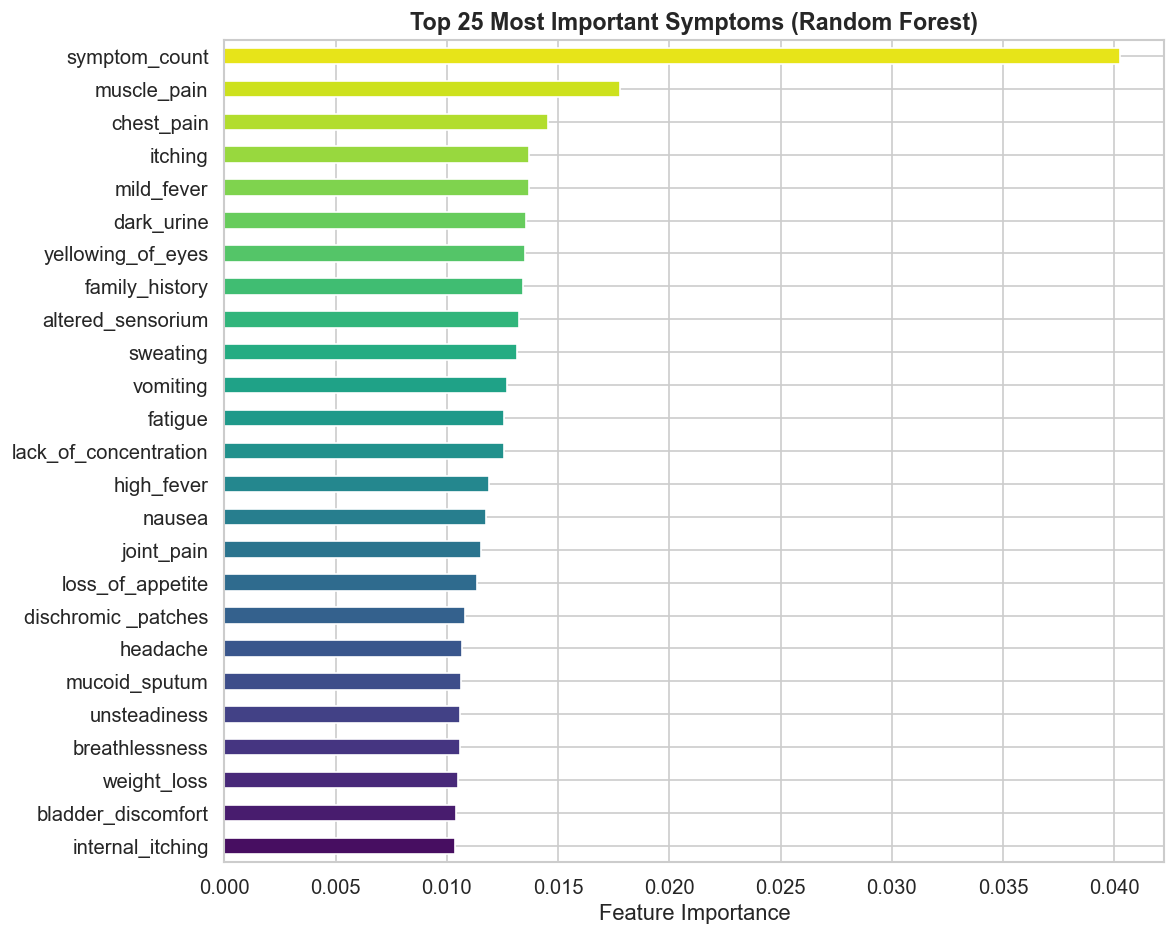

In [134]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top25 = importances.nlargest(25)

plt.figure(figsize=(10,8))

top25.sort_values().plot.barh(
    color=sns.color_palette("viridis", len(top25))
)

plt.xlabel("Feature Importance")
plt.title("Top 25 Most Important Symptoms (Random Forest)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Save Classification Report

In [135]:
y_pred = rf_model.predict(X_test)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True, zero_division=0)
).transpose()

report_df.to_csv("classification_report.csv")

print("classification_report.csv saved.")

report_df.head(10)

classification_report.csv saved.


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.000000,1.0
AIDS,1.0,1.0,1.000000,1.0
Acne,1.0,1.0,1.000000,1.0
Alcoholic hepatitis,1.0,1.0,1.000000,1.0
Allergy,1.0,1.0,1.000000,1.0
Arthritis,1.0,1.0,1.000000,1.0
Bronchial Asthma,1.0,1.0,1.000000,1.0
Cervical spondylosis,1.0,1.0,1.000000,1.0
Chicken pox,0.5,1.0,0.666667,1.0
Chronic cholestasis,1.0,1.0,1.000000,1.0


<a id="9"></a>
## 9. 📝 Conclusion

### Key Findings
- The dataset is **perfectly balanced** (120 samples per disease × 41 diseases = 4,920).
- All features are binary (0/1), representing symptom presence.
- **Random Forest** achieves near-perfect accuracy owing to the clean, structured, and large feature set.

### Results Summary

| Model | CV Accuracy | Test Accuracy |
|-------|------------|---------------|
| Random Forest | ~1.00 | ~1.00 |
| Logistic Regression | High | High |
| SVM (RBF) | High | High |

### Next Steps
- Integrate NLP for natural-language symptom input
- Add prediction confidence scores
- Expand dataset with more diseases and real-world noisy data
- Deploy via FastAPI (`app.py` + `func.py`)

---
*Notebook generated for the Disease Predictor project.*